In [1]:
import pandas as pd
import csv
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau



In [2]:
def load_data(v):
    with open(f'mutation_dataset_10-06_v{v}\\simulacoes_com_erro.pkl', 'rb') as arquivo:
        simulacoes_com_erro = pickle.load(arquivo)

    trees_cblv = np.load(f'mutation_dataset_10-06_v{v}\\tree_data.npy')
    trees_cblv = np.delete(trees_cblv, simulacoes_com_erro, axis=0)

    #R_0_1, infectuos time and a taxa relativa 
    # Retornando a segunda coluna (coluna referente ao R_nought)
    # e em segunda transformando a lista em um np.array

    tabela_de_parametros = np.load(f'mutation_dataset_10-06_v{v}\\tabela_parametros.npy')
    tabela_de_parametros = np.delete(tabela_de_parametros, simulacoes_com_erro, axis=0)

    R_nought1 = np.array([sublist[0] for sublist in tabela_de_parametros])
    R_nought2 = np.array([sublist[1] for sublist in tabela_de_parametros])
    infectious_time = np.array([sublist[8] for sublist in tabela_de_parametros])
    proportion_tr11_tr22 = np.array([sublist[10] for sublist in tabela_de_parametros])
    
    rescale_factors = np.load(f'mutation_dataset_10-06_v{v}\\rescale_factor.npy')
    rescale_factors = np.delete(rescale_factors, simulacoes_com_erro)

    infectious_time_div_reascale = np.round(infectious_time / rescale_factors, 3)

    mutation_masks = np.load(f'mutation_dataset_10-06_v{v}\\mutation_masks.npy')
    mutation_masks = np.delete(mutation_masks, simulacoes_com_erro, axis=0)

    vectorized = np.column_stack((R_nought1, R_nought2, infectious_time_div_reascale))
    masked = np.multiply(trees_cblv, mutation_masks)

    return trees_cblv, mutation_masks, rescale_factors

In [3]:
X, y, rescale_factors = load_data(4)

In [4]:
print(X.shape)
print(y.shape)

(99991, 1002)
(99991, 1002)


In [5]:
test_size = 5000
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=test_size,
    shuffle=False
)

In [6]:
y_train = y_train.reshape(-1, 501, 2)
y_test  = y_test.reshape(-1, 501, 2)

In [7]:
bce = tf.keras.losses.BinaryCrossentropy()

def dice_loss(y_true, y_pred):
    smooth = 1e-6

    intersection = tf.reduce_sum(y_true * y_pred, axis=[1, 2])
    denominator = tf.reduce_sum(y_true, axis=[1, 2]) + tf.reduce_sum(y_pred, axis=[1, 2])

    dice = (2.0 * intersection + smooth) / (denominator + smooth)

    return tf.reduce_mean(1.0 - dice)


def hole_loss(y_true, y_pred):
    left = y_pred[:, :-2, :]
    center = y_pred[:, 1:-1, :]
    right = y_pred[:, 2:, :]

    holes = left * (1.0 - center) * right

    return tf.reduce_mean(holes)


def mutation_mask_loss(y_true, y_pred):
    bce_value = bce(y_true, y_pred)
    dice_value = dice_loss(y_true, y_pred)
    hole_value = hole_loss(y_true, y_pred)

    return bce_value + dice_value + 0.1 * hole_value

In [9]:
'''modelo = tf.keras.models.Sequential([
    layers.Input(X_train[0].shape),
    layers.Reshape((501, 2)),
    layers.Conv1D(filters = 50, kernel_size = 3, activation='relu', padding='same'),
    layers.Conv1D(filters = 50, kernel_size = 10, activation='relu', padding='same'),
    layers.Conv1D(filters=32, kernel_size=3, activation='relu', padding='same'),
    layers.Conv1D(filters=2, kernel_size=1, activation='sigmoid', padding='same', name='mask')
    ])

modelo.compile(optimizer='adam',loss=mutation_mask_loss,
               metrics=['binary_crossentropy',
                        tf.keras.metrics.BinaryAccuracy(),
                        tf.keras.metrics.Precision(),
                        tf.keras.metrics.Recall()])
modelo.summary()'''

"modelo = tf.keras.models.Sequential([\n    layers.Input(X_train[0].shape),\n    layers.Reshape((501, 2)),\n    layers.Conv1D(filters = 50, kernel_size = 3, activation='relu', padding='same'),\n    layers.Conv1D(filters = 50, kernel_size = 10, activation='relu', padding='same'),\n    layers.Conv1D(filters=32, kernel_size=3, activation='relu', padding='same'),\n    layers.Conv1D(filters=2, kernel_size=1, activation='sigmoid', padding='same', name='mask')\n    ])\n\nmodelo.compile(optimizer='adam',loss=mutation_mask_loss,\n               metrics=['binary_crossentropy',\n                        tf.keras.metrics.BinaryAccuracy(),\n                        tf.keras.metrics.Precision(),\n                        tf.keras.metrics.Recall()])\nmodelo.summary()"

In [8]:
#modelo = tf.keras.models.load_model("modelos\\8000\\modelo.keras")

modelo = tf.keras.models.load_model("modelos\\8400\\modelo.keras", custom_objects={"mutation_mask_loss": mutation_mask_loss})


#modelo.summary()

In [10]:
early_stop = EarlyStopping(monitor='val_binary_crossentropy', mode='min', patience=25, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_binary_crossentropy', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

In [11]:
history = modelo.fit(X_train, y_train, epochs=200, batch_size=32, validation_split=0.1, callbacks=[early_stop])

Epoch 1/200
2672/2672 ━━━━━━━━━━━━━━━━━━━━ 146s 52ms/step - binary_accuracy: 0.8516 - binary_crossentropy: 0.3461 - loss: 0.8760 - precision: 0.7879 - recall: 0.7196 - val_binary_accuracy: 0.8552 - val_binary_crossentropy: 0.3404 - val_loss: 0.8709 - val_precision: 0.8061 - val_recall: 0.7074
Epoch 2/200
2672/2672 ━━━━━━━━━━━━━━━━━━━━ 137s 51ms/step - binary_accuracy: 0.8508 - binary_crossentropy: 0.3477 - loss: 0.8791 - precision: 0.7864 - recall: 0.7168 - val_binary_accuracy: 0.8550 - val_binary_crossentropy: 0.3422 - val_loss: 0.8708 - val_precision: 0.8030 - val_recall: 0.7111
Epoch 3/200
2672/2672 ━━━━━━━━━━━━━━━━━━━━ 137s 51ms/step - binary_accuracy: 0.8509 - binary_crossentropy: 0.3472 - loss: 0.8761 - precision: 0.7875 - recall: 0.7207 - val_binary_accuracy: 0.8550 - val_binary_crossentropy: 0.3407 - val_loss: 0.8729 - val_precision: 0.8059 - val_recall: 0.7069
Epoch 4/200
2672/2672 ━━━━━━━━━━━━━━━━━━━━ 137s 51ms/step - binary_accuracy: 0.8510 - binary_crossentropy: 0.3472 - lo

In [12]:
path = "modelos\\8300"

modelo.save(path + "\\modelo.keras")

#with open(path + "\\scaler.pkl", "wb") as f:
#    pickle.dump(scaler, f)

with open(path + "\\history.pkl", "wb") as f:
    pickle.dump(history.history, f)

In [9]:
pred_mask = modelo.predict(X_test)

157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step


In [47]:
# O ideal é nao discretizar, mas sim treinar com uma função perda
# que pune fortemente vales no meio das montanhas
# 
# tratar as árvores que são completamente mutadas



pred_mask[pred_mask < 0.75] = 0
pred_mask[pred_mask >= 0.75] = 1

In [10]:
pred_mask = pred_mask.reshape(-1, 1002)

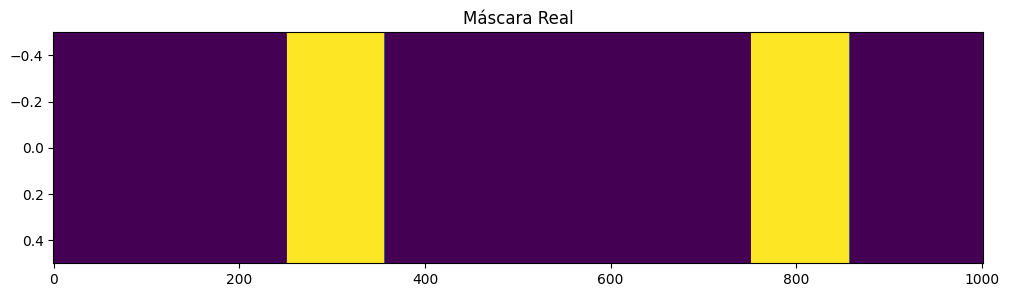

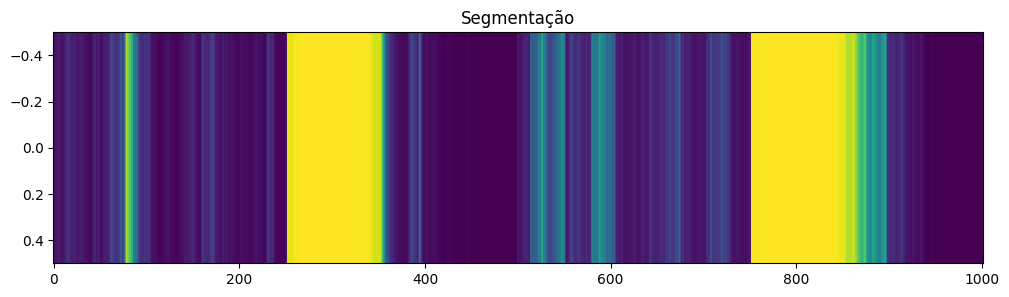

In [13]:
sample = 162
plt.figure(figsize=(12,3))
plt.imshow(y_test[sample].reshape(-1, 1002), aspect='auto')
plt.title("Máscara Real")
plt.savefig("mascara_real.pdf", bbox_inches="tight")
plt.show()

plt.figure(figsize=(12,3))
plt.imshow(pred_mask[sample].reshape(-1, 1002), aspect='auto')
plt.title("Segmentação")
plt.savefig("mascara_predizida.pdf", bbox_inches="tight")
plt.show()

In [ ]:
loss_bce = tf.keras.losses.BinaryCrossentropy()

atest_loss = loss_bce(y_test, pred_mask)

print("Test BCE:", float(atest_loss))

In [ ]:
loss_dice = tf.keras.losses.Dice()

btest_loss = loss_dice(y_test, pred_mask)

print("Test Dice Loss:", float(btest_loss))

Test Dice Loss: 0.31907790899276733


In [ ]:
loss_IoU = tf.keras.metrics.IoU(num_classes=2, target_class_ids=[0])

ctest_loss = loss_IoU(y_test, pred_mask)

print("Test IoU Loss:", float(ctest_loss))

Test IoU Loss: 0.6830438375473022


In [ ]:
print("Test BCE:", float(atest_loss))
print("Test Dice Loss:", float(btest_loss))
print("Test IoU Loss:", float(ctest_loss))

Test BCE: 0.3438544273376465
Test Dice Loss: 0.31907790899276733
Test IoU Loss: 0.6830438375473022


In [50]:
def load_data(v):
    with open(f'mutation_dataset_10-06_v{v}\\simulacoes_com_erro.pkl', 'rb') as arquivo:
        simulacoes_com_erro = pickle.load(arquivo)

    trees_cblv = np.load(f'mutation_dataset_10-06_v{v}\\tree_data.npy')
    trees_cblv = np.delete(trees_cblv, simulacoes_com_erro, axis=0)

    #R_0_1, infectuos time and a taxa relativa 
    # Retornando a segunda coluna (coluna referente ao R_nought)
    # e em segunda transformando a lista em um np.array

    tabela_de_parametros = np.load(f'mutation_dataset_10-06_v{v}\\tabela_parametros.npy')
    tabela_de_parametros = np.delete(tabela_de_parametros, simulacoes_com_erro, axis=0)

    R_nought1 = np.array([sublist[0] for sublist in tabela_de_parametros])
    R_nought2 = np.array([sublist[1] for sublist in tabela_de_parametros])
    infectious_time = np.array([sublist[8] for sublist in tabela_de_parametros])
    proportion_tr11_tr22 = np.array([sublist[10] for sublist in tabela_de_parametros])
    
    n_de_mutantes = np.load(f'mutation_dataset_10-06_v{v}\\number_of_mutantes.npy')
    n_de_mutantes = np.delete(n_de_mutantes, simulacoes_com_erro)
    sem_mutação = np.where(n_de_mutantes <= 5)
    R_nought2[sem_mutação[0]] = R_nought1[sem_mutação[0]]

    n_nos = np.count_nonzero(trees_cblv, axis=1)
    proporcao_mutacao = n_de_mutantes / n_nos
    muita_mutacao = np.where(proporcao_mutacao > 0.95)
    R_nought1[muita_mutacao[0]] = R_nought2[muita_mutacao[0]]

    rescale_factors = np.load(f'mutation_dataset_10-06_v{v}\\rescale_factor.npy')
    rescale_factors = np.delete(rescale_factors, simulacoes_com_erro)

    infectious_time_div_reascale = np.round(infectious_time / rescale_factors, 3)


    mutation_masks = np.load(f'mutation_dataset_10-06_v{v}\\mutation_masks.npy')
    mutation_masks = np.delete(mutation_masks, simulacoes_com_erro, axis=0)
    
    mutation_masks[-5000:] = pred_mask

    vectorized = np.column_stack((R_nought1, R_nought2, infectious_time_div_reascale))

    masked = np.multiply(trees_cblv, mutation_masks)
    trees_cblv_and_masked = np.column_stack((trees_cblv, masked))

    return trees_cblv_and_masked, vectorized, rescale_factors

In [51]:
X, y, rescale_factors = load_data(4)

In [52]:
test_size = 5000
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=test_size,
    shuffle=False
)

In [53]:
scaler = StandardScaler()
y_train = scaler.fit_transform(y_train)
y_test = scaler.transform(y_test)

In [54]:
modelo_mask_as_input = tf.keras.models.load_model("modelos\\9400\\modelo.keras")

modelo_mask_as_input.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 501, 4)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 499, 50)        │           650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 490, 50)        │        25,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 49, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 40, 80)         │        40,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 80)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         5,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 221,207 (864.09 KB)

 Trainable params: 73,735 (288.03 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 147,472 (576.07 KB)

In [55]:
pred = modelo_mask_as_input.predict(X_test)
pred = scaler.inverse_transform(pred)
pred[:, 2] *= rescale_factors[-test_size:]

157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


In [56]:
#run it once!
y_test = scaler.inverse_transform(y_test)
y_test[:, 2] *= rescale_factors[-test_size:]

In [57]:
mse_r01 = np.mean((pred[:,0] - y_test[:,0])**2)
mse_r02 = np.mean((pred[:,1] - y_test[:,1])**2)
mse_inf = np.mean((pred[:,2] - y_test[:,2])**2)



print("MSE R01:", mse_r01)
print("MSE R02:", mse_r02)
print("MSE Inf:", mse_inf)

MSE R01: 0.6672441762936913
MSE R02: 3.264488580979547
MSE Inf: 0.38848892468820195


In [58]:
erros = np.abs(pred - y_test)
mae_por_variavel = np.mean(erros, axis=0)

print("MAE R01:", mae_por_variavel[0])
print("MAE R02:", mae_por_variavel[1])
print("MAE Inf:", mae_por_variavel[2])

MAE R01: 0.4796887064601884
MAE R02: 1.371703788703821
MAE Inf: 0.4404700040832653


In [59]:
erro_relativo = np.mean(np.abs((pred - y_test) / y_test), axis=0)

print("MAPE R01:", erro_relativo[0])
print("MAPE R02:", erro_relativo[1])
print("MAPE Inf:", erro_relativo[2])

MAPE R01: 0.16490402228425172
MAPE R02: 0.3172032925388079
MAPE Inf: 0.07935447957149552


In [60]:
corr_r01 = np.corrcoef(y_test[:,0], pred[:,0])[0,1]
corr_r02 = np.corrcoef(y_test[:,1], pred[:,1])[0,1]
corr_inf = np.corrcoef(y_test[:,2], pred[:,2])[0,1]
print("CORR R01:", corr_r01)
print("CORR R02:", corr_r02)
print("CORR Inf:", corr_inf)

CORR R01: 0.8248147578713183
CORR R02: 0.8241623161986913
CORR Inf: 0.9716513812806671


In [35]:
print(f'''     & R01     & R02    & INF   \\\ \hline
MSE  & {mse_r01:.4f}  & {mse_r02:.4f} & {mse_inf:.4f} \\\ \hline
MAE  & {mae_por_variavel[0]:.4f} & {mae_por_variavel[1]:.4f} & {mae_por_variavel[2]:.4f} \\\ \hline
MAPE & {erro_relativo[0]:.4f}  & {erro_relativo[1]:.4f} & {erro_relativo[2]:.4f} \\\ \hline
CORR & {corr_r01:.4f}  & {corr_r02:.4f} & {corr_inf:.4f} \\\ \hline''')

     & R01     & R02    & INF   \\ \hline
MSE  & 0.6672  & 3.1824 & 0.3961 \\ \hline
MAE  & 0.4825 & 1.3545 & 0.4454 \\ \hline
MAPE & 0.1646  & 0.3119 & 0.0808 \\ \hline
CORR & 0.8269  & 0.8276 & 0.9714 \\ \hline
